In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
df = pd.read_csv("cnn_gru/data/metadata.csv")

In [3]:
df.columns

Index(['window_id', 'subjectID', 'dataset', 'taskID', 'isTurn', 'label',
       'overlap'],
      dtype='str')

Text(0.5, 1.0, 'Class Distribution by Dataset')

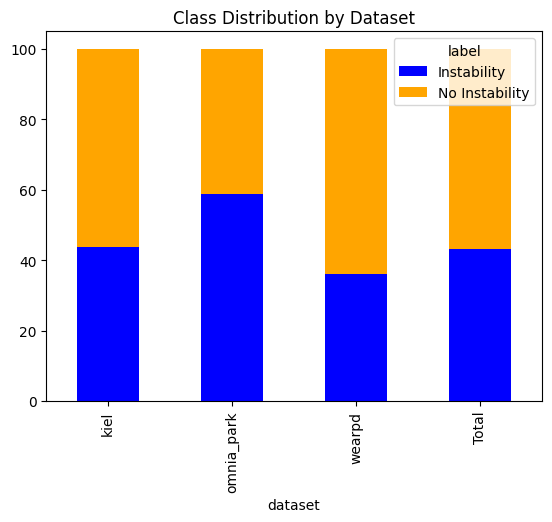

In [4]:
# plot class distribution for each dataset
class_colors = {
    0: "blue",
    1: "orange"}

df["label"] = df["label"].map({0: "No Instability", 1: "Instability", 2: "Instability", 3: "Instability"})  # Map classes to binary labels

# keep only one row for each tuple(subjectID, dataset) to avoid counting the same subject multiple times
df_new = df.drop_duplicates(subset=["subjectID", "dataset"])
# create percentage stacked bar plot
dataset_counts = df_new.groupby(["dataset", "label"]).size().unstack(fill_value=0)
dataset_percentages = (dataset_counts.div(dataset_counts.sum(axis=1), axis=0) )*100

# add total distribution considering all datasets together
total_counts = df_new.groupby("label").size()
total_percentages = (total_counts / total_counts.sum()) * 100
dataset_percentages.loc["Total"] = total_percentages
dataset_percentages.plot(kind="bar", stacked=True, color=[class_colors[0], class_colors[1]])
plt.title("Class Distribution by Dataset")

Number of subjects by dataset and task:
taskID      Stance  Walk
dataset                 
kiel            16    16
omnia_park      39    39
wearpd          86    86

Total number of subjects per dataset:
dataset
kiel          16
omnia_park    39
wearpd        86
Name: subjectID, dtype: int64

Number of unique tasks per subject in each dataset:
subjectID
1         2
10        2
100       2
102       2
11        2
         ..
wpd023    2
wpd024    2
wpd025    2
wpd026    2
wpd027    2
Length: 135, dtype: int64
Numero totale di soggetti con entrambi i task: 141


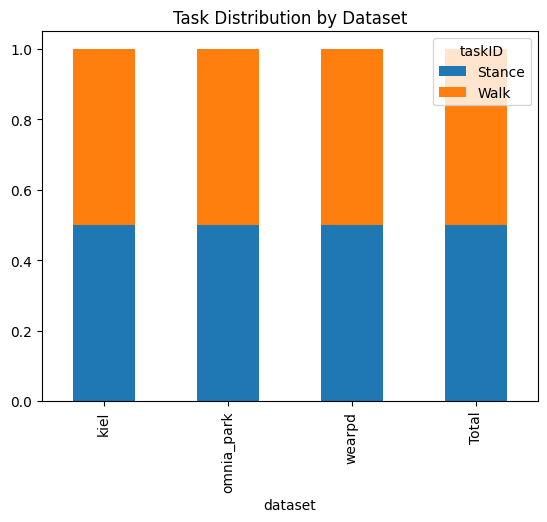

In [5]:
# task distribution by dataset
df["taskID"] = df["taskID"].map({0: "Stance", 1: "Stance", 2: "Walk"})
df = df.drop_duplicates(subset=["subjectID", "dataset", "taskID"])
task_counts = df.groupby(["dataset", "taskID"]).size().unstack(fill_value=0)
task_percentages = (task_counts.div(task_counts.sum(axis=1), axis=0))
total_counts = df.groupby("taskID").size()
total_percentages = (total_counts / total_counts.sum())
total_percentages.name = "Total"
task_percentages.loc["Total"] = total_percentages
task_percentages.plot(kind="bar", stacked=True)

plt.title("Task Distribution by Dataset")

# print how many subjects lack one task or the other in total and by dataset
task_counts = df.groupby(["dataset", "taskID"])["subjectID"].nunique().unstack(fill_value=0)
print("Number of subjects by dataset and task:")
print(task_counts)

# total number of subjects per dataset
subject_counts = df.groupby("dataset")["subjectID"].nunique()
print("\nTotal number of subjects per dataset:")
print(subject_counts)

# subjects with both tasks per dataset# 1. Conta quanti task unici ha ogni soggetto in ogni dataset
subjects_tasks = df.groupby(["dataset", "subjectID"])["taskID"].nunique()
task_per_subject = subjects_tasks.unstack(fill_value=0)
print("\nNumber of unique tasks per subject in each dataset:")
print(task_per_subject.sum())
total_subjects_both = (task_per_subject == 2).sum().sum()

print(f"Numero totale di soggetti con entrambi i task: {total_subjects_both}")